In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from datetime import timedelta

# Load raw data
df_readiness = pd.read_csv('dailyreadiness_2024-08-01_2025-05-01.csv')
df_sleep = pd.read_csv('sleep_2024-08-01_2025-05-01.csv')

# Load ovulation/menstruation data
cycle_df = pd.read_csv('cleaned_weeklydata.csv', parse_dates=['ovulation_date', 'menzie_start', 'menzie_end'])

# Clean data, drop rows with missing participant ID or ovulation date
cycle_df = cycle_df.dropna(subset=['ovulation_date'])
cycle_df['name'] = cycle_df['id_num'].astype(int) # ensure consistency with df_merged

# Filter to participants with ≥3 ovulation dates
valid_participants = cycle_df.groupby('id_num')['ovulation_date'].count()
valid_participants = valid_participants[valid_participants >= 3].index
cycle_df = cycle_df[cycle_df['id_num'].isin(valid_participants)]

In [35]:
!pip install plotly

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.8/9.8 MB 1.3 MB/s eta 0:00:0000:0100:010m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [plotly]2m1/2 [plotly]


In [29]:
# Phase dictionaries to hold dates per participant
phase_dates = {}

cycle_df['menzie_start'] = pd.to_datetime(cycle_df['menzie_start'], errors='coerce')
cycle_df['menzie_end'] = pd.to_datetime(cycle_df['menzie_end'], errors='coerce')
cycle_df['ovulation_date'] = pd.to_datetime(cycle_df['ovulation_date'], errors='coerce')

# Iterate over participants
from datetime import timedelta

for pid in valid_participants:
    df_p = cycle_df[cycle_df['id_num'] == pid].sort_values('ovulation_date')
    menstrual = set()
    follicular = set()
    ovulation = set()
    luteal = set()

    for i in range(len(df_p)):
        row = df_p.iloc[i]
        
        ov_date = row['ovulation_date']
        men_start = row['menzie_start']
        men_end = row['menzie_end']

        # If no ovulation date, we really can't do anything
        if pd.isnull(ov_date):
            continue

        # Default: estimate 13 days luteal, 14 days follicular
        est_men_end = ov_date - timedelta(days=14)
        est_men_start = est_men_end - timedelta(days=3)

        # menstrual phase
        if pd.notnull(men_start) and pd.notnull(men_end):
            menstrual.update(pd.date_range(men_start, men_end))
        else:
            menstrual.update(pd.date_range(est_men_start, est_men_end))

        # follicular phase
        follic_start = (men_end + timedelta(days=1)) if pd.notnull(men_end) else (est_men_end + timedelta(days=1))
        follic_end = ov_date - timedelta(days=1)
        if follic_start <= follic_end:
            follicular.update(pd.date_range(follic_start, follic_end))

        # ovulation phase
        ovulation.add(ov_date)

        # luteal phase
        if i + 1 < len(df_p) and pd.notnull(df_p.iloc[i + 1]['menzie_start']):
            next_men_start = df_p.iloc[i + 1]['menzie_start']
        else:
            next_men_start = ov_date + timedelta(days=13)
        luteal_start = ov_date + timedelta(days=1)
        luteal_end = next_men_start - timedelta(days=1)
        if luteal_start <= luteal_end:
            luteal.update(pd.date_range(luteal_start, luteal_end))

    phase_dates[pid] = {
        'menstrual': menstrual,
        'follicular': follicular,
        'ovulation': ovulation,
        'luteal': luteal
    }

# Count how many phase dates were actually added
for pid, phases in phase_dates.items():
    print(f"Participant {pid} phase lengths:")
    for phase, dates in phases.items():
        print(f"  {phase}: {len(dates)}")

Participant 10205 phase lengths:
  menstrual: 11
  follicular: 29
  ovulation: 3
  luteal: 27
Participant 10211 phase lengths:
  menstrual: 12
  follicular: 36
  ovulation: 3
  luteal: 34
Participant 10228 phase lengths:
  menstrual: 12
  follicular: 39
  ovulation: 3
  luteal: 36
Participant 10229 phase lengths:
  menstrual: 12
  follicular: 39
  ovulation: 3
  luteal: 36
Participant 10262 phase lengths:
  menstrual: 10
  follicular: 28
  ovulation: 3
  luteal: 26
Participant 10268 phase lengths:
  menstrual: 12
  follicular: 31
  ovulation: 3
  luteal: 29
Participant 10269 phase lengths:
  menstrual: 12
  follicular: 39
  ovulation: 3
  luteal: 36
Participant 10277 phase lengths:
  menstrual: 12
  follicular: 39
  ovulation: 3
  luteal: 36
Participant 10280 phase lengths:
  menstrual: 10
  follicular: 28
  ovulation: 3
  luteal: 26
Participant 10304 phase lengths:
  menstrual: 12
  follicular: 39
  ovulation: 3
  luteal: 36
Participant 10323 phase lengths:
  menstrual: 12
  follicula

In [39]:
# Merge readiness and sleep once, keep long sleeps, standardize columns

# Ensure keys exist
for df in (df_readiness, df_sleep):
    df['day'] = pd.to_datetime(df['day'], errors='coerce')
    # If 'name' isn't int in both, coerce:
    df['name'] = pd.to_numeric(df['name'], errors='coerce').astype('Int64')

# Merge on (day, name)
df_merged = pd.merge(
    df_readiness, df_sleep,
    on=['day', 'name'],
    how='inner',
    suffixes=('_ready', '_sleep')  # only matters if names clash
)

# Keep long sleeps only (adjust if your column name differs)
if 'type' in df_merged.columns:
    df_merged = df_merged[df_merged['type'] == 'long_sleep']

# Convert sleep seconds -> hours
df_merged['total_sleep_duration'] = pd.to_numeric(df_merged['total_sleep_duration'], errors='coerce') / 3600.0

# Keep participants that have phase calendars
valid_ids = set(phase_dates.keys())
df_merged = df_merged[df_merged['name'].isin(valid_ids)].copy()

# Align date types 1x
df_merged['day'] = df_merged['day'].dt.date
for pid in phase_dates:
    for phase in phase_dates[pid]:
        phase_dates[pid][phase] = {d.date() if hasattr(d, 'date') else d for d in phase_dates[pid][phase]}

# Default and assign phases
df_merged['phase'] = 'unknown'
for pid in phase_dates:
    for phase in ['menstrual', 'follicular', 'ovulation', 'luteal']:
        dates = phase_dates[pid][phase]
        mask = (df_merged['name'] == pid) & (df_merged['day'].isin(dates))
        df_merged.loc[mask, 'phase'] = phase

# Within-person z-scores (sleep and readiness)
df_merged['sleep_z'] = df_merged.groupby('name')['total_sleep_duration'].transform(
    lambda x: (x - x.mean()) / x.std()
)

# readiness column name is 'score' in your model—ensure numeric
df_merged['score'] = pd.to_numeric(df_merged['score'], errors='coerce')
df_merged['score_z'] = df_merged.groupby('name')['score'].transform(
    lambda x: (x - x.mean()) / x.std()
)

# drop "unknown" and rows with missing metrics
df_clean = df_merged.query("phase != 'unknown'").dropna(subset=['sleep_z', 'score_z', 'total_sleep_duration'])

# Make sure day column is datetime
df_merged['day'] = pd.to_datetime(df_merged['day'], errors='coerce')

# Keep only participants that have valid phase data
valid_ids = set(phase_dates.keys())
df_merged = df_merged[df_merged['name'].isin(valid_ids)]

# Standardize date format
df_merged['day'] = pd.to_datetime(df_merged['day']).dt.date

# Safely convert all date sets in phase_dates to .date format
for pid in phase_dates:
    for phase in phase_dates[pid]:
        cleaned_dates = set()
        for d in phase_dates[pid][phase]:
            try:
                cleaned_dates.add(d.date())  # for datetime objects
            except AttributeError:
                cleaned_dates.add(d)         # already a date
        phase_dates[pid][phase] = cleaned_dates

df_merged['day'] = pd.to_datetime(df_merged['day'], errors='coerce').dt.date

# Default to 'unknown'
df_merged['phase'] = 'unknown'

# Assign phases individually per participant
for pid in phase_dates:
    for phase in ['menstrual', 'follicular', 'ovulation', 'luteal']:
        date_set = phase_dates[pid][phase]
        mask = (df_merged['name'] == pid) & (df_merged['day'].isin(date_set))
        df_merged.loc[mask, 'phase'] = phase

print("Phase distribution after assignment:")
print(df_merged['phase'].value_counts())
print("\nExample participants with non-unknown phases:")
print(df_merged[df_merged['phase'] != 'unknown']['name'].unique()[:10])

print("Unique names in df_merged:", df_merged['name'].unique()[:10])
print("Keys in phase_dates:", list(phase_dates.keys())[:10])

#z-score
df_merged['total_sleep_duration'] /= 3600  # convert from seconds to hours

df_merged['sleep_z'] = df_merged.groupby('name')['total_sleep_duration'].transform(
    lambda x: (x - x.mean()) / x.std()
)
#drop unknown or missing data
df_clean = df_merged[(df_merged['phase'] != 'unknown') & (~df_merged['total_sleep_duration'].isna())]

print(df_clean['phase'].value_counts())
print(df_merged['phase'].value_counts())
print(df_merged['name'].nunique())  # how many participants total

print(df_merged['day'].dtype)
print(df_merged['day'].head())

Phase distribution after assignment:
phase
unknown       1652
follicular    1045
luteal         844
menstrual      228
ovulation       69
Name: count, dtype: int64

Example participants with non-unknown phases:
<IntegerArray>
[10277, 10328, 10323, 10335, 10205, 10211, 10304, 10262, 10403, 10435]
Length: 10, dtype: Int64
Unique names in df_merged: <IntegerArray>
[10277, 10328, 10323, 10335, 10205, 10211, 10304, 10262, 10403, 10435]
Length: 10, dtype: Int64
Keys in phase_dates: [10205, 10211, 10228, 10229, 10262, 10268, 10269, 10277, 10280, 10304]
phase
follicular    1045
luteal         844
menstrual      228
ovulation       69
Name: count, dtype: int64
phase
unknown       1652
follicular    1045
luteal         844
menstrual      228
ovulation       69
Name: count, dtype: int64
29
object
1602    2024-08-29
1603    2024-08-30
1604    2024-08-31
1605    2024-09-01
1606    2024-09-02
Name: day, dtype: object


In [31]:
# Run ANOVA and Tukey across all participants
from scipy.stats import f_oneway
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# One-way ANOVA
groups = [group['sleep_z'].values for name, group in df_clean.groupby('phase')]
f_stat, p_val = f_oneway(*groups)

# Tukey post-hoc
tukey = pairwise_tukeyhsd(endog=df_clean['sleep_z'], groups=df_clean['phase'], alpha=0.05)

print(f"ANOVA: F = {f_stat:.3f}, p = {p_val:.5f}")
print(tukey.summary())

ANOVA: F = 0.694, p = 0.55591
   Multiple Comparison of Means - Tukey HSD, FWER=0.05    
  group1     group2  meandiff p-adj   lower  upper  reject
----------------------------------------------------------
follicular    luteal   0.0445   0.66 -0.0552 0.1443  False
follicular menstrual   0.0428 0.9002 -0.1161 0.2016  False
follicular ovulation   0.1017 0.7595 -0.1644 0.3678  False
    luteal menstrual  -0.0018    1.0 -0.1643 0.1608  False
    luteal ovulation   0.0572 0.9472 -0.2112 0.3255  False
 menstrual ovulation    0.059  0.956 -0.2365 0.3544  False
----------------------------------------------------------


/var/folders/jy/f2b3fc396cbgchccs456w30r0000gn/T/ipykernel_19591/3374161262.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x='phase', y='sleep_z', palette='pastel')


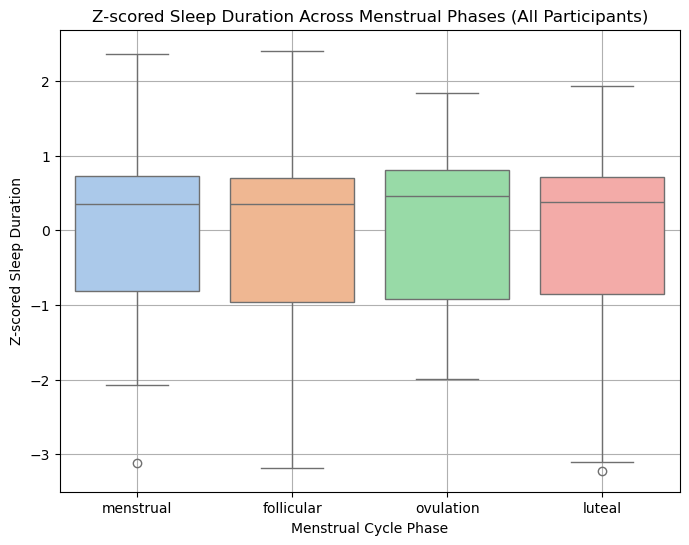

In [32]:
# Plot sleep across phases
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
sns.boxplot(data=df_clean, x='phase', y='sleep_z', palette='pastel')
plt.title('Z-scored Sleep Duration Across Menstrual Phases (All Participants)')
plt.xlabel('Menstrual Cycle Phase')
plt.ylabel('Z-scored Sleep Duration')
plt.grid(True)
plt.show()

                            OLS Regression Results                            
Dep. Variable:                  score   R-squared:                       0.019
Model:                            OLS   Adj. R-squared:                  0.018
Method:                 Least Squares   F-statistic:                     19.90
Date:                Wed, 13 Aug 2025   Prob (F-statistic):           9.07e-13
Time:                        18:30:53   Log-Likelihood:                -11323.
No. Observations:                3035   AIC:                         2.265e+04
Df Residuals:                    3031   BIC:                         2.268e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                                              coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------------

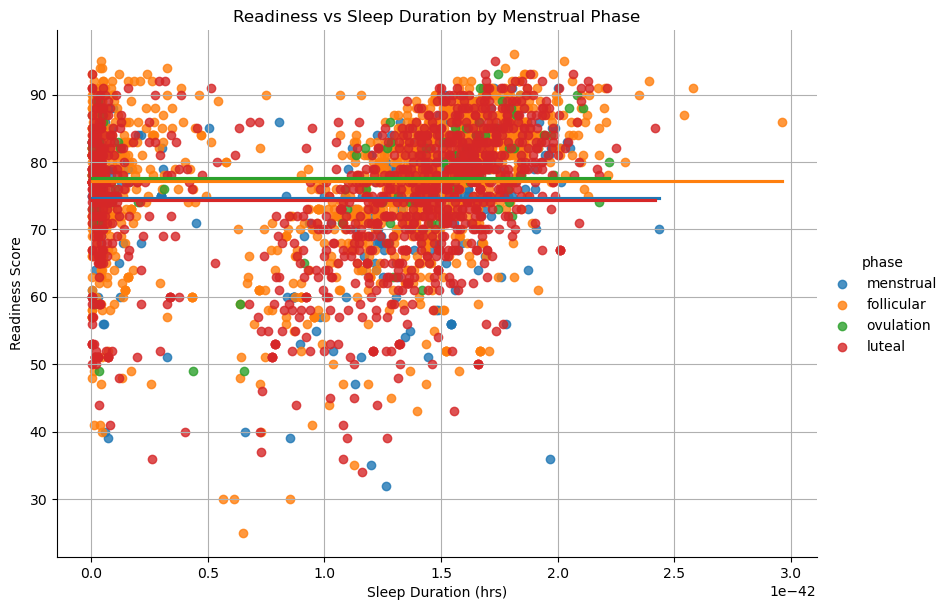

In [33]:
# Sleep–Readiness Regression by Phase
import statsmodels.formula.api as smf

# drop NaN readiness scores
df_model = df_clean.dropna(subset=['score'])

model = smf.ols('score ~ total_sleep_duration * phase', data=df_model).fit()
print(model.summary())

# plot
sns.lmplot(data=df_model, x='total_sleep_duration', y='score', hue='phase', ci=None, height=6, aspect=1.4)
plt.xlabel('Sleep Duration (hrs)')
plt.ylabel('Readiness Score')
plt.title('Readiness vs Sleep Duration by Menstrual Phase')
plt.grid(True)
plt.show()

In [42]:
import statsmodels.formula.api as smf

# Random intercept by participant - fixed effects for phase and sleep_z
m = smf.mixedlm("score_z ~ sleep_z * C(phase)", data=df_clean, groups=df_clean["name"])
mfit = m.fit(method='lbfgs')
print(mfit.summary())

                 Mixed Linear Model Regression Results
Model:                  MixedLM      Dependent Variable:      score_z   
No. Observations:       2186         Method:                  REML      
No. Groups:             29           Scale:                   0.7297    
Min. group size:        42           Log-Likelihood:          -2770.5876
Max. group size:        219          Converged:               Yes       
Mean group size:        75.4                                            
------------------------------------------------------------------------
                              Coef.  Std.Err.   z    P>|z| [0.025 0.975]
------------------------------------------------------------------------
Intercept                     -0.000    0.052 -0.000 1.000 -0.103  0.103
C(phase)[T.luteal]            -0.324    0.040 -8.181 0.000 -0.401 -0.246
C(phase)[T.menstrual]         -0.334    0.063 -5.336 0.000 -0.457 -0.211
C(phase)[T.ovulation]         -0.080    0.108 -0.742 0.458 -0.292  0.

/opt/anaconda3/envs/dailyreadinessvsleep/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:1634: UserWarning:

Random effects covariance is singular

/opt/anaconda3/envs/dailyreadinessvsleep/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning:

The MLE may be on the boundary of the parameter space.



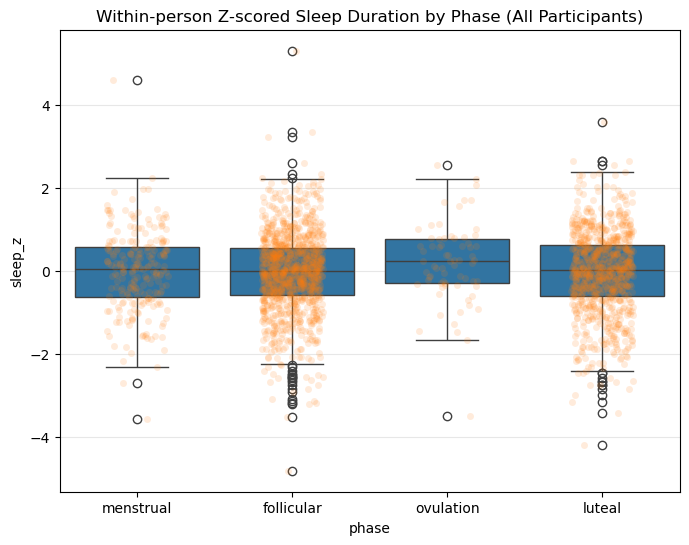

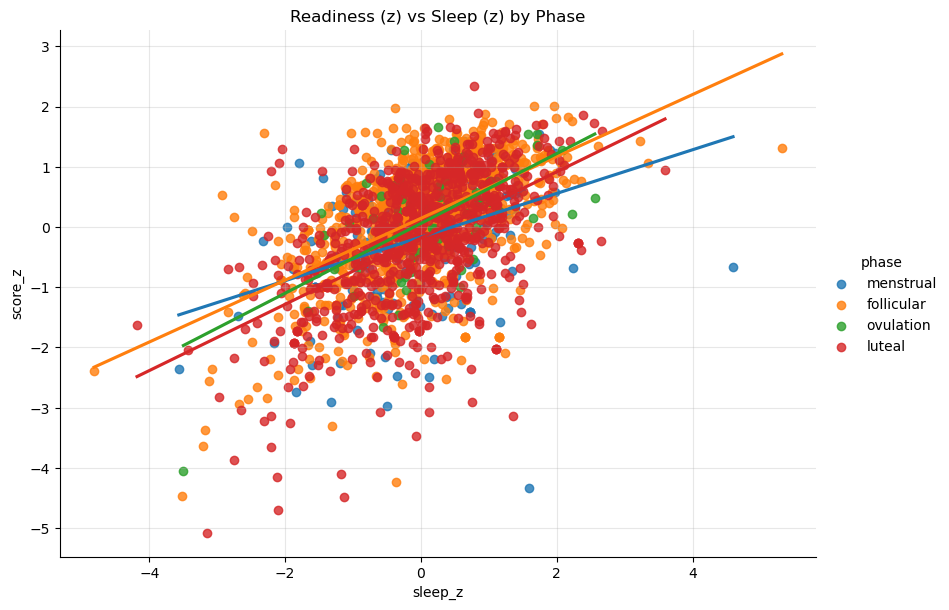

In [41]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.boxplot(data=df_clean, x='phase', y='sleep_z')
sns.stripplot(data=df_clean, x='phase', y='sleep_z', alpha=0.15, jitter=0.2)
plt.title('Within-person Z-scored Sleep Duration by Phase (All Participants)')
plt.grid(True, axis='y', alpha=0.3)
plt.show()

# Readiness vs sleep, colored by phase (z-scored, pooled)
sns.lmplot(data=df_clean, x='sleep_z', y='score_z', hue='phase', ci=None, height=6, aspect=1.4)
plt.title('Readiness (z) vs Sleep (z) by Phase')
plt.grid(True, alpha=0.3)
plt.show()

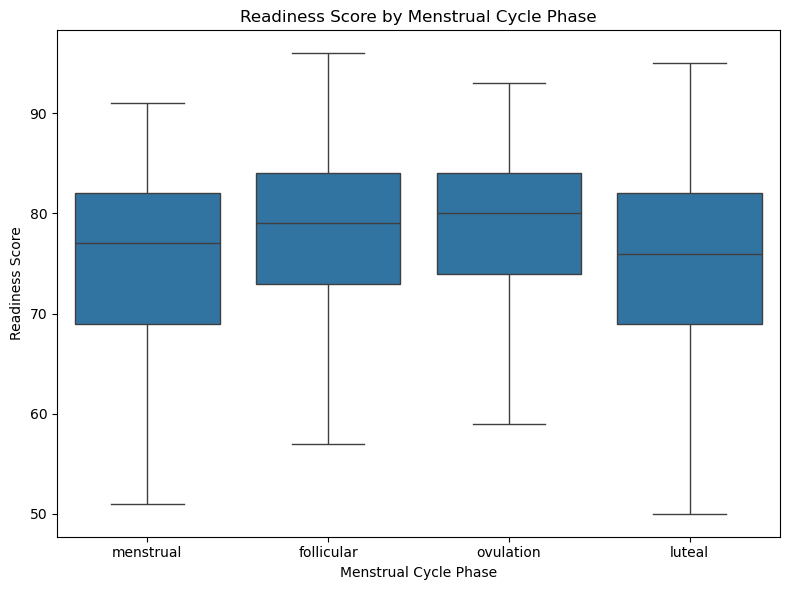

In [48]:
import seaborn as sns
import matplotlib.pyplot as plt

order = ['menstrual','follicular','ovulation','luteal']  # consistent phase order

plt.figure(figsize=(8,6))
sns.boxplot(data=df_clean, x='phase', y='score', order=order, showfliers=False)

#sns.stripplot(data=df_clean.sample(1200, random_state=0), x='phase', y='score', order=order, color='k', alpha=0.15, jitter=0.15, marker='.', size=2)
plt.title("Readiness Score by Menstrual Cycle Phase")
plt.xlabel("Menstrual Cycle Phase")
plt.ylabel("Readiness Score")
plt.tight_layout()
plt.show()

/var/folders/jy/f2b3fc396cbgchccs456w30r0000gn/T/ipykernel_19591/397043626.py:2: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



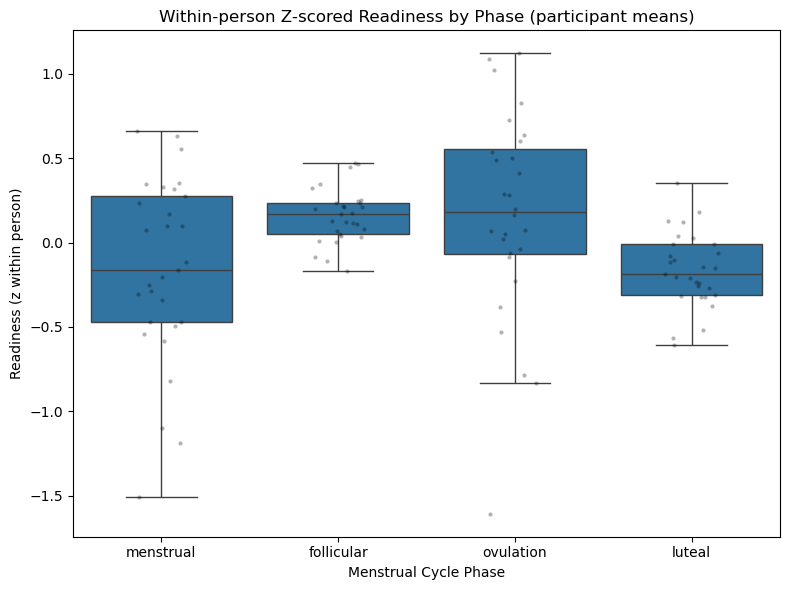

In [49]:
# within-person z
df_clean['score_z'] = df_clean.groupby('name')['score'] \
                              .transform(lambda x: (x - x.mean()) / x.std())

df_phase_mean_z = (df_clean
                   .groupby(['name','phase'], as_index=False)['score_z']
                   .mean())

plt.figure(figsize=(8,6))
sns.boxplot(data=df_phase_mean_z, x='phase', y='score_z', order=order, showfliers=False)
sns.stripplot(data=df_phase_mean_z, x='phase', y='score_z', order=order,
              color='k', alpha=0.3, jitter=0.15, size=3)
plt.title("Within-person Z-scored Readiness by Phase (participant means)")
plt.xlabel("Menstrual Cycle Phase")
plt.ylabel("Readiness (z within person)")
plt.tight_layout()
plt.show()

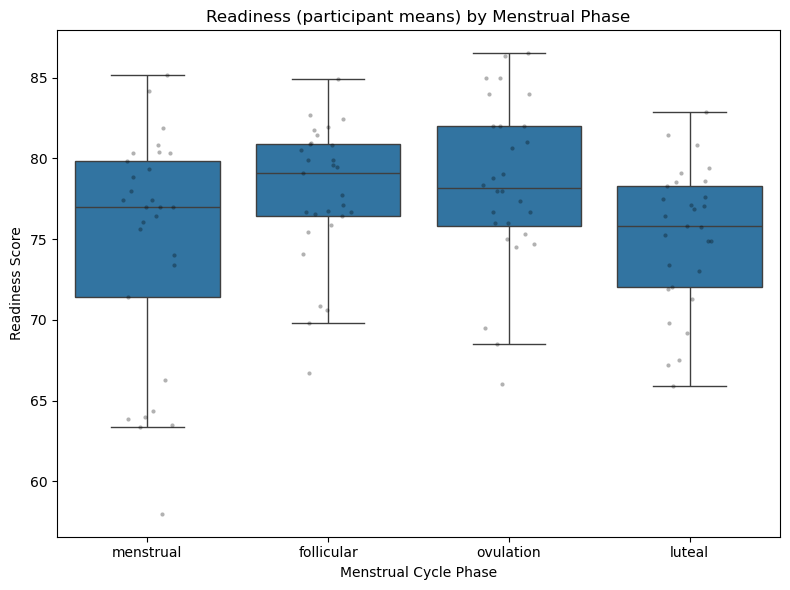

In [50]:
# one mean per person per phase
df_phase_mean = (df_clean
                 .groupby(['name','phase'], as_index=False)['score']
                 .mean())

plt.figure(figsize=(8,6))
sns.boxplot(data=df_phase_mean, x='phase', y='score', order=order, showfliers=False)
sns.stripplot(data=df_phase_mean, x='phase', y='score', order=order,
              color='k', alpha=0.3, jitter=0.15, size=3)
plt.title("Readiness (participant means) by Menstrual Phase")
plt.xlabel("Menstrual Cycle Phase")
plt.ylabel("Readiness Score")
plt.tight_layout()
plt.show()